In [186]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [187]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap


In [188]:
df = pd.read_csv('/content/StockPriceDataset.csv')

In [189]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,16.893808,392467600,AAPL
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,16.985926,412610800,AAPL
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,16.864458,317209200,AAPL
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,16.971254,258529600,AAPL


In [190]:
df.shape

(25160, 8)

In [191]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64
Ticker,object


In [192]:
# Drop duplicates and irrelevant column
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (25160, 8)


In [193]:
#Basic Preprocessing

# Ensure date is datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Fill missing values if any
df.fillna(method='ffill', inplace=True)


/tmp/ipython-input-1479835622.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [194]:
#Feature Engineering

# Price change
df['Price_Change'] = df['Close'] - df['Open']
df['Price_Change_Percent'] = (df['Close'] - df['Open']) / df['Open'] * 100

# Moving Averages
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()



In [195]:
# RSI
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

In [196]:
# MACD
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

In [197]:
# Bollinger Bands
df['BB_Mid'] = df['Close'].rolling(20).mean()
df['BB_Std'] = df['Close'].rolling(20).std()
df['BB_Upper'] = df['BB_Mid'] + 2 * df['BB_Std']
df['BB_Lower'] = df['BB_Mid'] - 2 * df['BB_Std']

In [198]:
#Additional Technical Indicators

# On-Balance Volume (OBV)
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

# Average True Range (ATR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
df['ATR'] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1).rolling(14).mean()

# Commodity Channel Index (CCI)
tp = (df['High'] + df['Low'] + df['Close']) / 3
sma_tp = tp.rolling(20).mean()
mad = tp.rolling(20).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
df['CCI'] = (tp - sma_tp) / (0.015 * mad)

# Stochastic Oscillator %K and %D
low_14 = df['Low'].rolling(14).min()
high_14 = df['High'].rolling(14).max()
df['%K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
df['%D'] = df['%K'].rolling(3).mean()


In [199]:
# Lagged features (extended: past 5 days)
lag_features = ['Close', 'Volume', 'SMA_5', 'RSI_14', 'MACD', '%K', '%D', 'ATR', 'CCI', 'OBV']
for f in lag_features:
    for lag in range(1, 6):  # 1-5 days lag
        df[f'{f}_lag{lag}'] = df[f].shift(lag)


In [200]:
# Drop initial rows with NaN from indicators
df.dropna(inplace=True)

In [201]:
#Target Variable

df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df = df[:-1]

In [202]:
#Features & Scaling

feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Price_Change', 'Price_Change_Percent',
    'SMA_5', 'SMA_10', 'EMA_5', 'EMA_10',
    'RSI_14', 'MACD', 'MACD_Signal',
    'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower',
    'OBV', 'ATR', 'CCI', '%K', '%D'
]
for f in lag_features:
    for lag in range(1, 6):
        feature_cols.append(f'{f}_lag{lag}')

X = df[feature_cols]
y = df['Target']

In [203]:
# Scale features

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [204]:
#Train/Test Split

train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [205]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [206]:
y.value_counts()


,count
Target,
1,12615
0,12520


In [207]:
X_train.shape

(20108, 73)

In [208]:
X_test.shape

(5027, 73)

In [209]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential()
model.add(Dense(256, input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

# Lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [210]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/100
503/503 - 16s - 32ms/step - accuracy: 0.7299 - loss: 0.5398 - val_accuracy: 0.7024 - val_loss: 0.6645
Epoch 2/100
503/503 - 7s - 14ms/step - accuracy: 0.7622 - loss: 0.4859 - val_accuracy: 0.7352 - val_loss: 0.5090
Epoch 3/100
503/503 - 5s - 9ms/step - accuracy: 0.7682 - loss: 0.4768 - val_accuracy: 0.7268 - val_loss: 0.5599
Epoch 4/100
503/503 - 4s - 7ms/step - accuracy: 0.7703 - loss: 0.4708 - val_accuracy: 0.7765 - val_loss: 0.4650
Epoch 5/100
503/503 - 3s - 6ms/step - accuracy: 0.7725 - loss: 0.4734 - val_accuracy: 0.7568 - val_loss: 0.4845
Epoch 6/100
503/503 - 3s - 5ms/step - accuracy: 0.7752 - loss: 0.4676 - val_accuracy: 0.7384 - val_loss: 0.5592
Epoch 7/100
503/503 - 3s - 5ms/step - accuracy: 0.7771 - loss: 0.4624 - val_accuracy: 0.7643 - val_loss: 0.5208
Epoch 8/100
503/503 - 3s - 5ms/step - accuracy: 0.7771 - loss: 0.4675 - val_accuracy: 0.7558 - val_loss: 0.4991
Epoch 9/100
503/503 - 3s - 7ms/step - accuracy: 0.7750 - loss: 0.4638 - val_accuracy: 0.7805 - val_lo

In [211]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-Score:", f1)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.7684503680127313
Precision: 0.7376936316695353
Recall: 0.8420432220039292
F1-Score: 0.7864220183486239
AUC: 0.8655237157435303
Confusion Matrix:
 [[1720  762]
 [ 402 2143]]


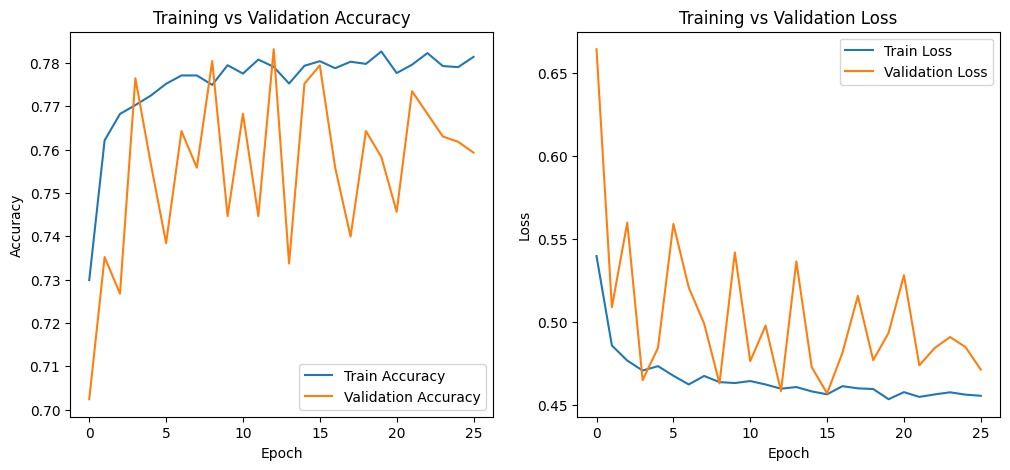

In [212]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


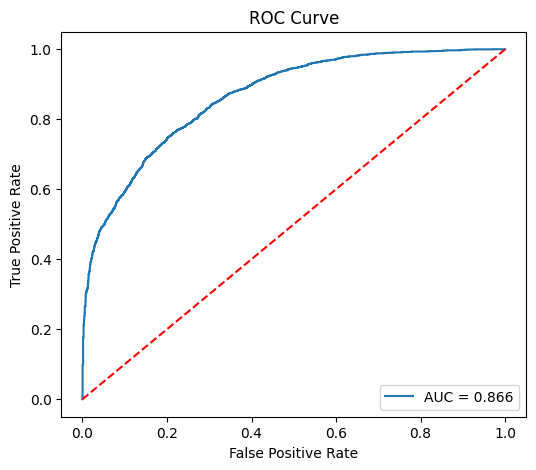

In [213]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
